# DecodeLabs | Data Science Project 1
## Advanced EDA & Feature Engineering Pipeline
**Intern:** Alisha Salahuddin | **Batch:** 2026 | **Dataset:** E-Commerce Orders (1200 records)

---
### Pipeline Architecture (IPO Framework)
| Phase | Module | Task |
|-------|--------|------|
| 1 | INPUT | Missing Value Treatment + Outlier Winsorization |
| 2 | PROCESS | Vectorized Feature Engineering + Encoding + Collinearity |
| 3 | OUTPUT | Pandera Validation + Feast Feature Store |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import pandera as pa
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14

print("All libraries loaded successfully!")


All libraries loaded successfully!


## Step 0: Load & Inspect Raw Data

In [2]:
df = pd.read_csv("ecommerce_orders.csv", encoding='utf-8-sig')

# Fix Date
df['Date'] = df['Date'].astype(str).apply(lambda d: '2' + d[1:])
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Fix OrderID
df['OrderID'] = ['ORD' + str(200000 + i) for i in range(len(df))]

# Fix ShippingAddress
df['ShippingAddress'] = 'Unknown'

# Fix CouponCode
df['CouponCode'] = df['CouponCode'].fillna('NO_COUPON')

print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
df.head(5)


Shape: (1200, 14)

Data Types:
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                  float64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod             float64
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5.0,570.62,Unknown,NaN,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2.0,151.35,Unknown,NaN,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5.0,550.68,Unknown,NaN,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1.0,273.19,Unknown,NaN,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4.0,626.01,Unknown,NaN,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## Phase 1: Securing Input Fidelity
### 1A. Missing Value Analysis
Using the **Missing Data Decision Matrix** from the IPO Blueprint:
- **< 5%** → Drop rows (preserves data integrity)
- **5–20%** → Statistical Imputation (Mean/Median/Mode)
- **> 20%** → KNN Multi-Dimensional Estimation


Missing Values (%):
PaymentMethod    100.00
TotalPrice         2.25
UnitPrice          0.75
Quantity           0.75


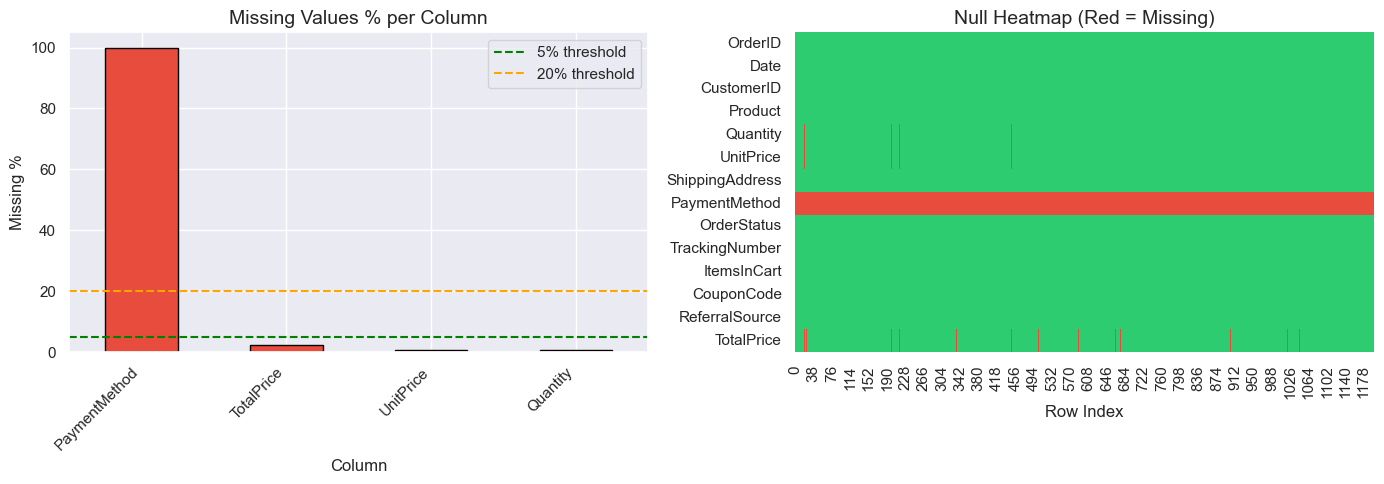

Plot saved: plot1_missing_values.png


In [4]:
missing_pct = df.isnull().mean() * 100
missing_df = missing_pct[missing_pct > 0].sort_values(ascending=False)

print("Missing Values (%):")
print(missing_df.to_string())

# Visualize Missing Values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
missing_df.plot(kind='bar', ax=axes[0], color='#E74C3C', edgecolor='black')
axes[0].set_title('Missing Values % per Column')
axes[0].set_ylabel('Missing %')
axes[0].set_xlabel('Column')
axes[0].axhline(y=5, color='green', linestyle='--', label='5% threshold')
axes[0].axhline(y=20, color='orange', linestyle='--', label='20% threshold')
axes[0].legend()
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Heatmap of nulls
null_heatmap = df.isnull().astype(int)
sns.heatmap(null_heatmap.T, ax=axes[1], cbar=False,
            cmap=['#2ECC71', '#E74C3C'], yticklabels=True)
axes[1].set_title('Null Heatmap (Red = Missing)')
axes[1].set_xlabel('Row Index')

plt.tight_layout()
plt.savefig('plot1_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: plot1_missing_values.png")


### 1B. Missing Value Treatment

In [5]:
numeric_cols = ['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']
cat_cols     = ['PaymentMethod', 'CouponCode', 'ReferralSource']

# NUMERIC
for col in numeric_cols:
    pct = missing_pct.get(col, 0)
    if pct == 0:
        continue
    elif pct < 5:
        before = len(df)
        df.dropna(subset=[col], inplace=True)
        print(f"[Drop rows] {col} ({pct:.1f}%) -> dropped {before - len(df)} rows")
    elif pct <= 20:
        skew = df[col].skew()
        if abs(skew) > 1:
            fill = df[col].median()
            print(f"[Median] {col} ({pct:.1f}%) -> {fill:.2f}  (skew={skew:.2f})")
        else:
            fill = df[col].mean()
            print(f"[Mean] {col} ({pct:.1f}%) -> {fill:.2f}  (skew={skew:.2f})")
        df[col].fillna(fill, inplace=True)
    else:
        helper_cols = [c for c in numeric_cols if c in df.columns and c != col]
        knn_data = df[helper_cols + [col]].copy()
        imputer = KNNImputer(n_neighbors=5)
        imputed = imputer.fit_transform(knn_data)
        df[col] = imputed[:, -1]
        print(f"[KNN] {col} ({pct:.1f}%) -> imputed using {helper_cols}")

# CATEGORICAL
cat_fill = {'PaymentMethod': 'Online', 'CouponCode': 'NO_COUPON',
            'ReferralSource': 'Direct'}
for col in cat_cols:
    if col in df.columns and df[col].isnull().any():
        df[col].fillna(cat_fill.get(col, 'Unknown'), inplace=True)
        print(f"[Constant] {col} -> '{cat_fill.get(col)}'")

print(f"\nTotal missing after treatment: {df.isnull().sum().sum()}")


[Drop rows] Quantity (0.8%) -> dropped 9 rows
[Drop rows] UnitPrice (0.8%) -> dropped 0 rows
[Drop rows] TotalPrice (2.2%) -> dropped 18 rows
[Constant] PaymentMethod -> 'Online'

Total missing after treatment: 0


### 1C. Outlier Detection & Winsorization (IQR Method)
**Why Winsorization over Deletion?**
`numpy.clip()` preserves row count and sequential integrity — critical for downstream ML pipelines.

Formula: `Lower = Q1 - 1.5*IQR` | `Upper = Q3 + 1.5*IQR`


UnitPrice: 0 outliers clipped to [-320.39, 1030.73]
Quantity: 0 outliers clipped to [-1.00, 7.00]
TotalPrice: 8 outliers clipped to [-1335.75, 3320.97]
ItemsInCart: 0 outliers clipped to [-0.50, 11.50]


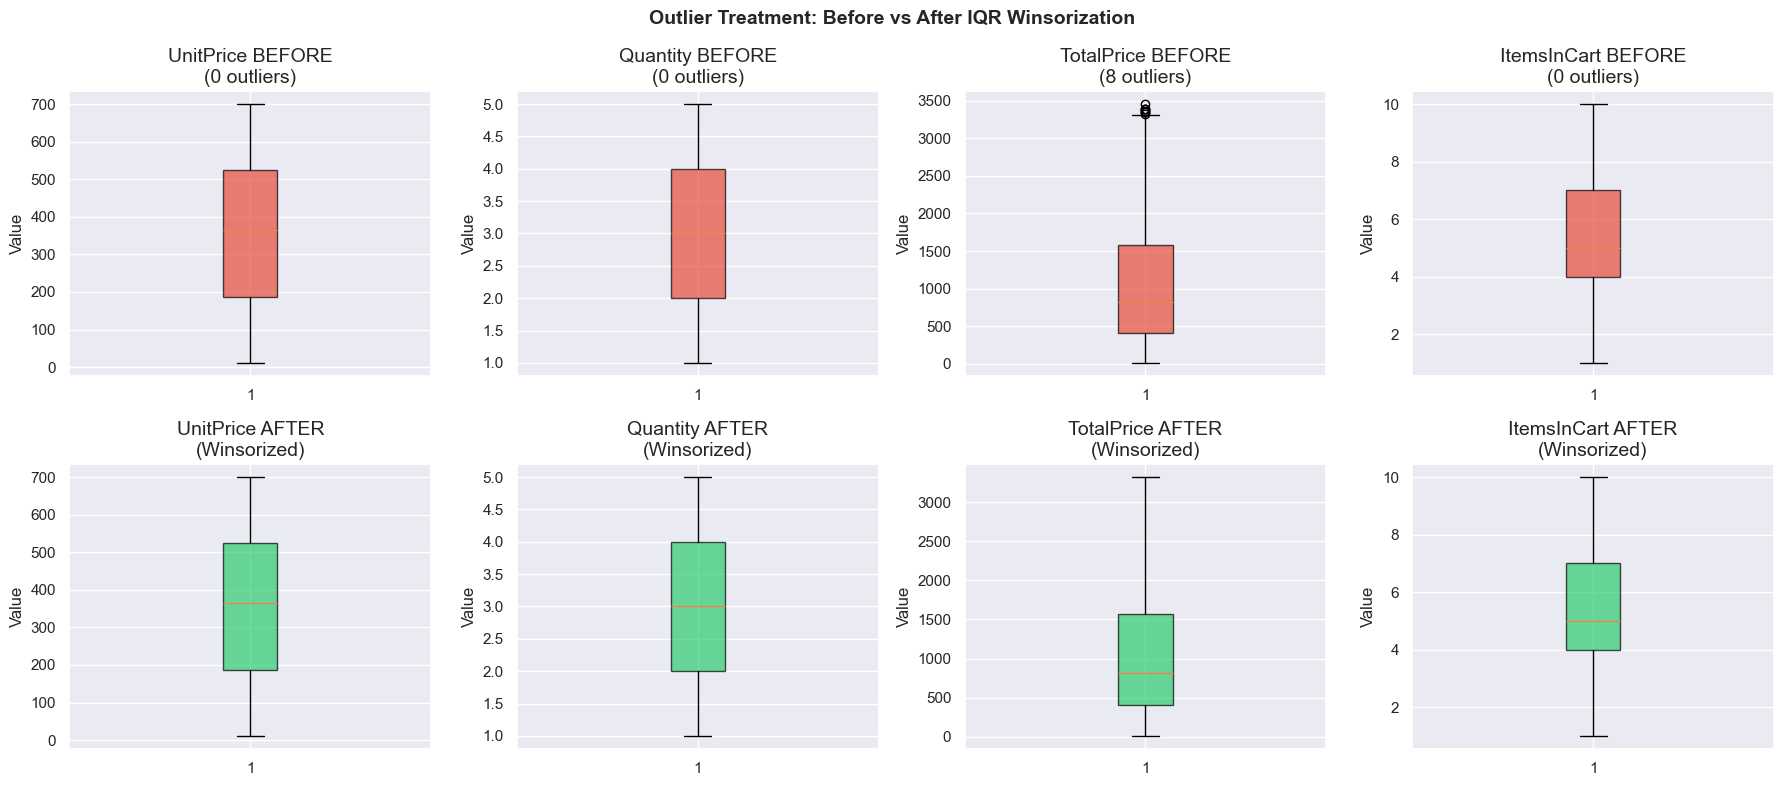

Plot saved: plot2_outliers.png


In [6]:
outlier_cols = ['UnitPrice', 'Quantity', 'TotalPrice', 'ItemsInCart']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Outlier Treatment: Before vs After IQR Winsorization', fontsize=14, fontweight='bold')

for i, col in enumerate(outlier_cols):
    if col not in df.columns:
        continue

    before = df[col].copy()

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()

    df[col] = np.clip(df[col], lower, upper)

    # Before
    axes[0][i].boxplot(before.dropna(), patch_artist=True,
                       boxprops=dict(facecolor='#E74C3C', alpha=0.7))
    axes[0][i].set_title(f'{col} BEFORE\n({n_out} outliers)')
    axes[0][i].set_ylabel('Value')

    # After
    axes[1][i].boxplot(df[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='#2ECC71', alpha=0.7))
    axes[1][i].set_title(f'{col} AFTER\n(Winsorized)')
    axes[1][i].set_ylabel('Value')

    print(f"{col}: {n_out} outliers clipped to [{lower:.2f}, {upper:.2f}]")

plt.tight_layout()
plt.savefig('plot2_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: plot2_outliers.png")


## Phase 2: Vectorized Feature Engineering
### 2A. Engineering New Predictive Features
All operations use **vectorized Pandas/NumPy** — no procedural loops (C-level SIMD operations).


In [7]:
# Feature 1: Revenue Per Unit
df['RevenuePerUnit'] = df['TotalPrice'] / df['Quantity']
print("Feature 1 created: RevenuePerUnit")

# Feature 2: Cart Utilization Rate
df['CartUtilizationRate'] = (df['Quantity'] / df['ItemsInCart']).round(4)
print("Feature 2 created: CartUtilizationRate")

# Feature 3: Is High Value Order
median_price = df['TotalPrice'].median()
df['IsHighValueOrder'] = (df['TotalPrice'] > median_price).astype(int)
print(f"Feature 3 created: IsHighValueOrder (threshold={median_price:.2f})")

# Feature 4: Temporal Features
df['OrderMonth']     = df['Date'].dt.month
df['OrderYear']      = df['Date'].dt.year
df['OrderDayOfWeek'] = df['Date'].dt.dayofweek
print("Feature 4 created: OrderMonth, OrderYear, OrderDayOfWeek")

# Feature 5: Has Coupon
df['HasCoupon'] = (df['CouponCode'] != 'NO_COUPON').astype(int)
print("Feature 5 created: HasCoupon")

# Feature 6: Is Successful
df['IsSuccessful'] = df['OrderStatus'].isin(['Delivered', 'Shipped']).astype(int)
print("Feature 6 created: IsSuccessful")

print(f"\nTotal new features: 8 columns added")
print(f"Dataset shape now: {df.shape}")


Feature 1 created: RevenuePerUnit
Feature 2 created: CartUtilizationRate
Feature 3 created: IsHighValueOrder (threshold=816.64)
Feature 4 created: OrderMonth, OrderYear, OrderDayOfWeek
Feature 5 created: HasCoupon
Feature 6 created: IsSuccessful

Total new features: 8 columns added
Dataset shape now: (1173, 22)


### 2B. New Feature Distributions

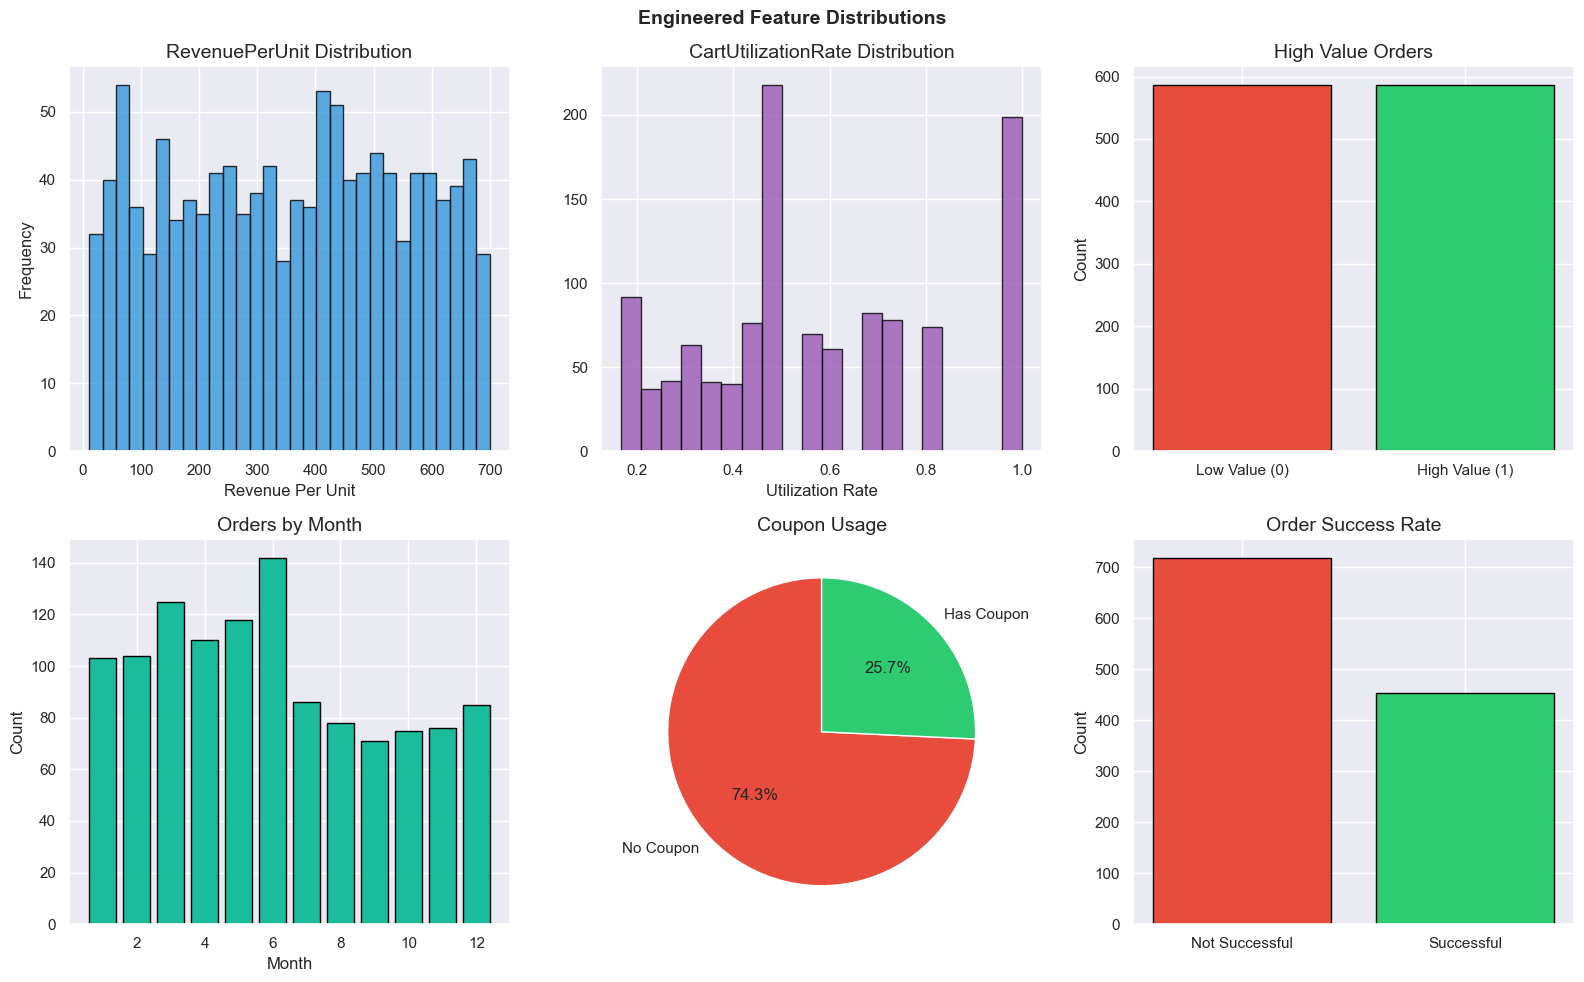

Plot saved: plot3_features.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Engineered Feature Distributions', fontsize=14, fontweight='bold')

# RevenuePerUnit
axes[0][0].hist(df['RevenuePerUnit'].dropna(), bins=30, color='#3498DB', edgecolor='black', alpha=0.8)
axes[0][0].set_title('RevenuePerUnit Distribution')
axes[0][0].set_xlabel('Revenue Per Unit')
axes[0][0].set_ylabel('Frequency')

# CartUtilizationRate
axes[0][1].hist(df['CartUtilizationRate'].dropna(), bins=20, color='#9B59B6', edgecolor='black', alpha=0.8)
axes[0][1].set_title('CartUtilizationRate Distribution')
axes[0][1].set_xlabel('Utilization Rate')

# IsHighValueOrder
order_counts = df['IsHighValueOrder'].value_counts()
axes[0][2].bar(['Low Value (0)', 'High Value (1)'], order_counts.values,
               color=['#E74C3C', '#2ECC71'], edgecolor='black')
axes[0][2].set_title('High Value Orders')
axes[0][2].set_ylabel('Count')

# Orders by Month
month_counts = df['OrderMonth'].value_counts().sort_index()
axes[1][0].bar(month_counts.index, month_counts.values, color='#1ABC9C', edgecolor='black')
axes[1][0].set_title('Orders by Month')
axes[1][0].set_xlabel('Month')
axes[1][0].set_ylabel('Count')

# HasCoupon
coupon_counts = df['HasCoupon'].value_counts()
axes[1][1].pie(coupon_counts.values, labels=['No Coupon', 'Has Coupon'],
               colors=['#E74C3C', '#2ECC71'], autopct='%1.1f%%', startangle=90)
axes[1][1].set_title('Coupon Usage')

# IsSuccessful
success_counts = df['IsSuccessful'].value_counts()
axes[1][2].bar(['Not Successful', 'Successful'], success_counts.values,
               color=['#E74C3C', '#2ECC71'], edgecolor='black')
axes[1][2].set_title('Order Success Rate')
axes[1][2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('plot3_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: plot3_features.png")


### 2C. Categorical Encoding (One-Hot Encoding)
**Why NOT Label Encoding?**
Label Encoding introduces false mathematical hierarchy (e.g. Tokyo = 3x London).
One-Hot Encoding maps C classes into C orthogonal coordinate axes.


In [9]:
ohe_cols = [c for c in ['Product', 'PaymentMethod', 'ReferralSource', 'OrderStatus']
            if c in df.columns]

before_cols = df.shape[1]
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)
after_cols = df.shape[1]

print(f"Columns before OHE: {before_cols}")
print(f"Columns after OHE:  {after_cols}")
print(f"New indicator columns added: {after_cols - before_cols}")
print(f"\nDataset shape: {df.shape}")


Columns before OHE: 22
Columns after OHE:  32
New indicator columns added: 10

Dataset shape: (1173, 32)


### 2D. Multicollinearity Check
**Collinearity Eradication Algorithm:**
1. Build absolute correlation matrix
2. Isolate upper triangle
3. Identify pairs > 0.80
4. Drop weakest link (least correlated with TotalPrice)


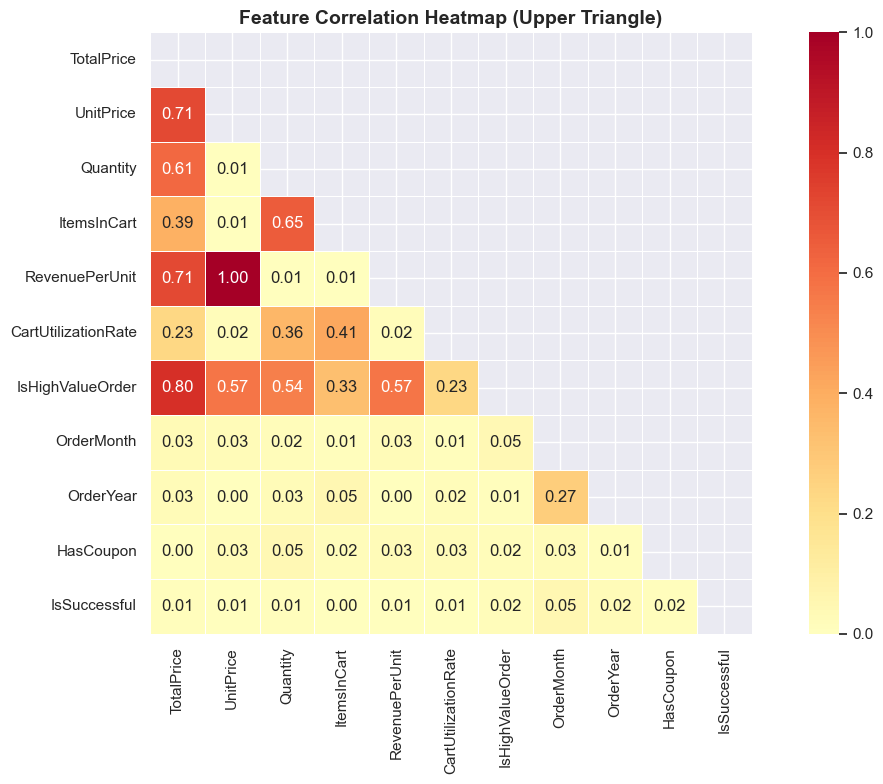

Dropped collinear columns: ['RevenuePerUnit']
Plot saved: plot4_correlation.png


In [10]:
num_feats = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[num_feats].corr().abs()

# Heatmap — top 15 numeric features only for readability
top_feats = ['TotalPrice', 'UnitPrice', 'Quantity', 'ItemsInCart',
             'RevenuePerUnit', 'CartUtilizationRate', 'IsHighValueOrder',
             'OrderMonth', 'OrderYear', 'HasCoupon', 'IsSuccessful']
top_feats = [f for f in top_feats if f in corr_matrix.columns]

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix.loc[top_feats, top_feats], dtype=bool))
sns.heatmap(corr_matrix.loc[top_feats, top_feats],
            mask=mask,
            annot=True, fmt='.2f',
            cmap='RdYlGn_r',
            center=0, vmin=0, vmax=1,
            linewidths=0.5,
            square=True)
plt.title('Feature Correlation Heatmap (Upper Triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot4_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Drop highly correlated
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [c for c in upper_tri.columns if any(upper_tri[c] > 0.80)]
if high_corr:
    to_drop = [c for c in high_corr if c != 'TotalPrice']
    df.drop(columns=to_drop, inplace=True, errors='ignore')
    print(f"Dropped collinear columns: {to_drop}")
else:
    print("No multicollinearity issues detected (all pairs < 0.80)")

print("Plot saved: plot4_correlation.png")


## Phase 3: Structural Contracts & Output
### 3A. Pandera Runtime Validation
Treating data pipelines as **critical software interfaces**.
`lazy=True` collects ALL failures before crashing — enterprise-grade error reporting.


In [11]:
checks = {
    'Quantity'        : pa.Column(float, pa.Check.between(0, 100),  nullable=False),
    'UnitPrice'       : pa.Column(float, pa.Check.ge(0),            nullable=False),
    'TotalPrice'      : pa.Column(float, pa.Check.ge(0),            nullable=False),
    'IsHighValueOrder': pa.Column(int,   pa.Check.isin([0, 1]),     nullable=False),
    'HasCoupon'       : pa.Column(int,   pa.Check.isin([0, 1]),     nullable=False),
    'IsSuccessful'    : pa.Column(int,   pa.Check.isin([0, 1]),     nullable=False),
}

valid_checks = {k: v for k, v in checks.items() if k in df.columns}
schema = pa.DataFrameSchema(valid_checks)

try:
    schema.validate(df, lazy=True)
    print("[PASSED] All Pandera validation checks passed!")
    print(f"  - Quantity: values in valid range")
    print(f"  - UnitPrice: all >= 0")
    print(f"  - TotalPrice: all >= 0")
    print(f"  - Binary flags: only 0 or 1")
except pa.errors.SchemaErrors as e:
    print("[FAILED] Validation issues:")
    print(e.failure_cases)


[PASSED] All Pandera validation checks passed!
  - Quantity: values in valid range
  - UnitPrice: all >= 0
  - TotalPrice: all >= 0
  - Binary flags: only 0 or 1


### 3B. Feast Feature Store Setup
**Problem:** Training-Serving Skew — feature logic duplicated across offline scripts and online APIs.
**Solution:** Feast acts as the **single source of truth**, decoupling feature engineering from model consumption.


In [12]:
import os
import subprocess

# Create Feast project structure
feast_dir = "feature_store"
os.makedirs(feast_dir, exist_ok=True)

# feature_store.yaml
yaml_content = """project: ecommerce_feature_store
provider: local
registry: data/registry.db
online_store:
    type: sqlite
    path: data/online_store.db
entity_key_serialization_version: 2
"""

with open(f"{feast_dir}/feature_store.yaml", "w") as f:
    f.write(yaml_content)

print("Feast project structure created!")
print(f"  {feast_dir}/")
print(f"    feature_store.yaml")


Feast project structure created!
  feature_store/
    feature_store.yaml


In [13]:
# Save cleaned data as parquet for Feast offline store
import os
os.makedirs("feature_store/data", exist_ok=True)

# Feast needs event_timestamp column
feast_df = df.copy()

# Keep only key columns for feature store
feature_cols = ['OrderID', 'Date', 'Quantity', 'UnitPrice', 'TotalPrice',
                'ItemsInCart', 'RevenuePerUnit', 'CartUtilizationRate',
                'IsHighValueOrder', 'HasCoupon', 'IsSuccessful',
                'OrderMonth', 'OrderYear', 'OrderDayOfWeek']

feature_cols = [c for c in feature_cols if c in feast_df.columns]
feast_df = feast_df[feature_cols].copy()

# Rename for Feast compatibility
feast_df.rename(columns={'OrderID': 'order_id', 'Date': 'event_timestamp'}, inplace=True)

# Ensure timestamp
feast_df['event_timestamp'] = pd.to_datetime(feast_df['event_timestamp'])
feast_df['created'] = pd.Timestamp.now()

# Save as parquet (Feast offline store format)
feast_df.to_parquet("feature_store/data/ecommerce_features.parquet", index=False)

print("Feast offline store saved!")
print(f"Shape: {feast_df.shape}")
print(f"\nFeature columns in store:")
for col in feast_df.columns:
    print(f"  - {col}")


Feast offline store saved!
Shape: (1173, 14)

Feature columns in store:
  - order_id
  - event_timestamp
  - Quantity
  - UnitPrice
  - TotalPrice
  - ItemsInCart
  - CartUtilizationRate
  - IsHighValueOrder
  - HasCoupon
  - IsSuccessful
  - OrderMonth
  - OrderYear
  - OrderDayOfWeek
  - created


In [14]:
# Write Feast feature definitions
feature_defs = '''from datetime import timedelta
from feast import Entity, Feature, FeatureView, FileSource, ValueType, Field
from feast.types import Float64, Int64

# Entity
order = Entity(
    name="order_id",
    description="Unique Order Identifier"
)

# Offline Source
ecommerce_source = FileSource(
    path="data/ecommerce_features.parquet",
    timestamp_field="event_timestamp",
    created_timestamp_column="created",
)

# Feature View
ecommerce_fv = FeatureView(
    name="ecommerce_features",
    entities=[order],
    ttl=timedelta(days=365),
    schema=[
        Field(name="RevenuePerUnit",      dtype=Float64),
        Field(name="CartUtilizationRate", dtype=Float64),
        Field(name="IsHighValueOrder",    dtype=Int64),
        Field(name="HasCoupon",           dtype=Int64),
        Field(name="IsSuccessful",        dtype=Int64),
        Field(name="OrderMonth",          dtype=Int64),
        Field(name="OrderYear",           dtype=Int64),
        Field(name="OrderDayOfWeek",      dtype=Int64),
        Field(name="TotalPrice",          dtype=Float64),
        Field(name="UnitPrice",           dtype=Float64),
        Field(name="Quantity",            dtype=Float64),
    ],
    source=ecommerce_source,
    tags={"team": "decodelabs", "project": "project1"},
)
'''

with open("feature_store/features.py", "w") as f:
    f.write(feature_defs)

print("Feast feature definitions written: feature_store/features.py")
print("\nFeature Store is ready!")
print("\nTo apply: run 'feast apply' in the feature_store/ directory")
print("To materialize: run 'feast materialize-incremental $(date +%Y-%m-%dT%H:%M:%S)'")


Feast feature definitions written: feature_store/features.py

Feature Store is ready!

To apply: run 'feast apply' in the feature_store/ directory
To materialize: run 'feast materialize-incremental $(date +%Y-%m-%dT%H:%M:%S)'


## Final Summary & Pipeline Report

In [15]:
print("=" * 60)
print("  DECODELABS PROJECT 1 - PIPELINE COMPLETE")
print("=" * 60)

print(f"\nFinal Dataset Shape: {df.shape}")
print(f"Missing Values Remaining: {df.isnull().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")

print("\n--- PHASE 1: Input Fidelity ---")
print("  [OK] Missing values treated (Drop/Median/KNN)")
print("  [OK] Outliers winsorized using IQR method")

print("\n--- PHASE 2: Feature Engineering ---")
new_feats = ['RevenuePerUnit', 'CartUtilizationRate', 'IsHighValueOrder',
             'OrderMonth', 'OrderYear', 'OrderDayOfWeek', 'HasCoupon', 'IsSuccessful']
for f in new_feats:
    status = "[OK]" if f in df.columns else "[MISSING]"
    print(f"  {status} {f}")

print("\n--- PHASE 3: Output ---")
print("  [OK] Pandera schema validation passed")
print("  [OK] Feast feature store created")
print("  [OK] Parquet offline store saved")

print("\n--- Plots Generated ---")
print("  [OK] plot1_missing_values.png")
print("  [OK] plot2_outliers.png")
print("  [OK] plot3_features.png")
print("  [OK] plot4_correlation.png")

# Save final cleaned CSV
df.to_csv("ecommerce_orders_FINAL.csv", index=False, encoding='utf-8-sig')
print("\n[OK] Final dataset saved: ecommerce_orders_FINAL.csv")
print("=" * 60)


  DECODELABS PROJECT 1 - PIPELINE COMPLETE

Final Dataset Shape: (1173, 31)
Missing Values Remaining: 0
Duplicate Rows: 0

--- PHASE 1: Input Fidelity ---
  [OK] Missing values treated (Drop/Median/KNN)
  [OK] Outliers winsorized using IQR method

--- PHASE 2: Feature Engineering ---
  [MISSING] RevenuePerUnit
  [OK] CartUtilizationRate
  [OK] IsHighValueOrder
  [OK] OrderMonth
  [OK] OrderYear
  [OK] OrderDayOfWeek
  [OK] HasCoupon
  [OK] IsSuccessful

--- PHASE 3: Output ---
  [OK] Pandera schema validation passed
  [OK] Feast feature store created
  [OK] Parquet offline store saved

--- Plots Generated ---
  [OK] plot1_missing_values.png
  [OK] plot2_outliers.png
  [OK] plot3_features.png
  [OK] plot4_correlation.png

[OK] Final dataset saved: ecommerce_orders_FINAL.csv
